## Iran Job Market Analysis
###  Project Overview
This project analyzes the Iranian job market by collecting thousands of job advertisements from JobVision.
The primary objective is to explore hiring trends, required technical skills, salary ranges, experience requirements, and regional demand across software engineering and data-related positions.
The analysis will also prepare the dataset for subsequent machine learning tasks and predictive modeling.

In [97]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings; warnings.filterwarnings("ignore")

plt.style.use("ggplot")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 100)

DATA_PATH = "../data/processed/jobs_merge.csv"


In [98]:
df = pd.read_csv(DATA_PATH)
df.head()

,keyword,job_id,title,company,province,city,salary_visible,internship,remote,urgent,experience_years,source,scraped_at,description,work_type,seniority,category,company_size,industries,benefits,salary_title,salary_min,salary_max,gender,required_age_min,required_age_max,military,work_days,business_trip,software,software_levels,first_activation,activation,expire,application_count
0,python,1396130,برنامه نویس Python,بارکس,تهران,تهران,False,False,False,True,5,NaN,NaN,<div style='direction: rtl; text-align: right;'>ما برای توسعه ERP شرکت بر پایه Odoo به دنبال یک ...,Full Time,Senior Specialist,"IT - Software Development (Web,Moblie,…)",11 - 50 employees,Transportation / Logistics,"Loan,Bonus,Snacks\r\n,Occasional packages and gifts\r\n",NaN,NaN,NaN,Men / Women,NaN,NaN,False,شنبه تا چهارشنبه 8ت5پنج شنبه از 8صبح الی2,NaN,"Python,Oracle Database,GIT","Advanced,Basic,Basic",2026-05-20T15:30:13Z,2026-05-20T15:30:13Z,2026-07-19T15:30:13Z,504.0
1,python,1401623,Senior Backend Engineer(Python/FastAPI)- Shoraka,بیمه بازار,تهران,تهران,False,False,True,True,3,NaN,NaN,"<p dir=""ltr""><span style=""font-size: 12pt"">We are looking for a Senior Backend Engineer to join ...",Full Time,Senior Specialist,"IT - Software Development (Web,Moblie,…)",501 - 1000 employees,"Internet Provider / E-commerce / Online Services,Insurance",NaN,NaN,NaN,NaN,Men / Women,NaN,NaN,False,Saturday to Wednesday,NaN,"Python,PostgreSql,Prometheus,Gerafana,Docker,Redis,Kubernetes","Advanced,Intermediate,Intermediate,Intermediate,Intermediate,Intermediate,Intermediate",2026-05-25T14:52:25,2026-06-14T14:52:28,2026-07-24T14:52:25,813.0
2,python,1436012,برنامه نویس Python,ارتباطات فرهنگ آزما,تهران,تهران,False,False,False,False,2,NaN,NaN,<p>ما در تیم تحقیق و توسعه <strong>فرهنگ آزما </strong>به دنبال یک توسعه دهنده Backend هستیم تا ...,Full Time,Specialist,"IT - Software Development (Web,Moblie,…)",11 - 50 employees,"IT / Software / Hardware,Internet Provider / E-commerce / Online Services",Occasional packages and gifts\r\n,NaN,NaN,NaN,Men / Women,22.0,40.0,False,شنبه تا چهارشنبه 8:30 الی 18,NaN,"Python,Django,GIT,MySql,PostgreSql,Redis,Linux,Rest API,Unit Testing","Advanced,Advanced,Advanced,Intermediate,Intermediate,Basic,Intermediate,Intermediate,Basic",2026-07-11T10:36:12Z,2026-07-11T10:36:12Z,2026-09-09T10:36:12Z,414.0
3,python,1390562,برنامه نویس بک‌اند (Python/Django),شرکت بیمۀ زندگی باران,تهران,تهران,False,False,False,True,3,NaN,NaN,"<div dir=""rtl"" style=""text-align:right;""><p><strong>اگر توسعه‌دهنده‌ای هستید که چالش‌های فنی شما...",Full Time,Specialist,"IT - Software Development (Web,Moblie,…)",11 - 50 employees,Insurance,"Loan,Bonus,Health insurance\r\n,Flexible working hours\r\n,Learning stipends\r\n,Purchasing coup...",NaN,NaN,NaN,Men / Women,23.0,33.0,True,شنبه تا سه شنبه از 08:00 الی 17:00 و چهارشنبه از ساعت 08:00 الی ساعت 16:00 (با یک ساعت شناوری صبح),NaN,"Python,Django,GIT,Linux","Intermediate,Intermediate,Basic,Basic",2026-05-25T09:28:51Z,2026-06-14T09:28:52Z,2026-07-24T09:28:51Z,889.0
4,python,1429358,برنامه نویس Python,شرکت پیشگامان توسعه ارتباطات,تهران,تهران,False,False,False,False,2,NaN,NaN,"<div dir=""rtl"" style=""text-align:right""><p>نکات فنی:</p><ul><li>تسلط بر Django</li><li>آشنایی با...",Full Time,Specialist,"IT - Software Development (Web,Moblie,…)",201 - 500 employees,"IT / Software / Hardware,Internet Provider / E-commerce / Online Services","Health insurance\r\n,Occasional packages and gifts\r\n",NaN,NaN,NaN,Men / Women,19.0,40.0,True,شنبه تا سه‌شنبه 8 تا 17، چهارشنبه 8 تا 16,NaN,"Linux,Django,GIT,Python","Intermediate,Advanced,Intermediate,Intermediate",2026-06-22T15:16:03Z,2026-06-22T15:16:03Z,2026-08-21T15:16:03Z,611.0


In [99]:
df["title"].value_counts()

title
نگهبان - آقا                             142
کارشناس فروش                             134
ادمین شبکه های اجتماعی                    95
مدیر فروش                                 87
طراح گرافیک                               81
                                        ... 
معلم دبستان (پایه اول) - خانم              1
کارشناس فروش (هاست)                        1
کارشناس فروش سازمانی (راهکارهای ابری)      1
تدوینگر و تولید محتوا                      1
کارشناس فروش پر انرژی - خانم               1
Name: count, Length: 6855, dtype: int64

In [100]:
df[df["title"] =="نگهبان - آقا"]["category"]

4327     Security Guard
8477     Security Guard
8485     Security Guard
8489     Security Guard
8493     Security Guard
              ...      
12357    Security Guard
12358    Security Guard
12359    Security Guard
12361    Security Guard
12363    Security Guard
Name: category, Length: 142, dtype: str

In [101]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 12640 entries, 0 to 12639
Data columns (total 35 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   keyword            12640 non-null  str    
 1   job_id             12640 non-null  int64  
 2   title              12640 non-null  str    
 3   company            12640 non-null  str    
 4   province           12617 non-null  str    
 5   city               12640 non-null  str    
 6   salary_visible     12640 non-null  bool   
 7   internship         12037 non-null  object 
 8   remote             12037 non-null  object 
 9   urgent             12037 non-null  object 
 10  experience_years   12640 non-null  int64  
 11  source             603 non-null    str    
 12  scraped_at         603 non-null    str    
 13  description        12636 non-null  str    
 14  work_type          12636 non-null  str    
 15  seniority          12636 non-null  str    
 16  category           12636 non-null

In [102]:
df.isna().sum().sum()

np.int64(81348)

In [103]:
overview = pd.DataFrame({
    "Metric": [
        "Total Job Posts",
        "Unique Companies",
        "Unique Provinces",
        "Unique Cities",
        "Unique Job Titles"
    ],
    "Value": [
        len(df),
        df["company"].nunique(),
        df["province"].nunique(),
        df["city"].nunique(),
        df["title"].nunique()
    ]
})

overview

,Metric,Value
0,Total Job Posts,12640
1,Unique Companies,6071
2,Unique Provinces,31
3,Unique Cities,264
4,Unique Job Titles,6855


In [104]:
missing = (df.isna().sum().to_frame("Missing"))
missing["Percentage"] = (missing["Missing"] / len(df) * 100).round(2)
missing = (missing.query("Missing > 0").sort_values("Percentage", ascending=False))
missing

,Missing,Percentage
scraped_at,12037,95.23
source,12037,95.23
business_trip,11576,91.58
salary_title,8360,66.14
salary_min,8360,66.14
salary_max,8360,66.14
required_age_min,4251,33.63
required_age_max,4172,33.01
software_levels,3677,29.09
software,3677,29.09


In [105]:
print(f"Memory Usage (MB): {df.memory_usage(deep=True).sum() / 1024 ** 2:.2f}")

Memory Usage (MB): 56.94


# **Market Landscape**

##  Hiring Demand Analysis
This section explores the hiring demand across different job positions to identify the most frequently advertised roles in the Iranian technology job market.

## Job Titles

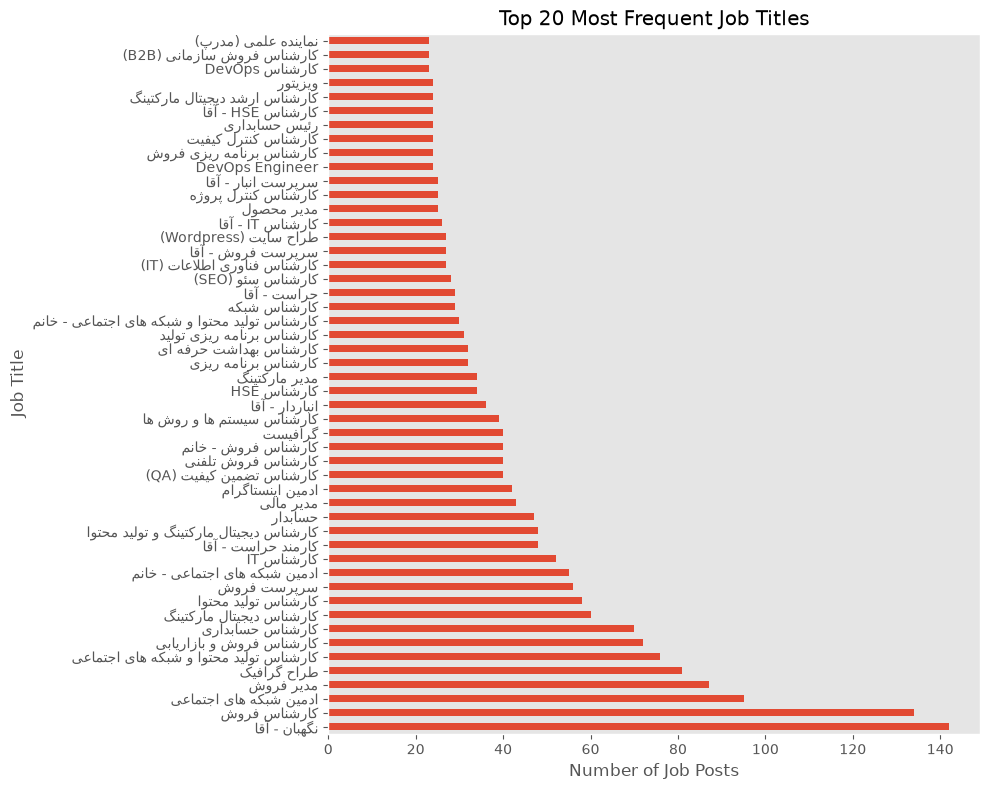

In [106]:
title_counts = df["title"].value_counts()[:50]
title_counts.head(50).plot(kind="barh", figsize=(10,8))
plt.title("Top 20 Most Frequent Job Titles"); plt.grid()
plt.xlabel("Number of Job Posts"); plt.ylabel("Job Title")
plt.tight_layout(); plt.show()

In [107]:
# How concentrated is the job market?
title_distribution = (df["title"].value_counts(normalize=True).mul(100))
top10_share = title_distribution.head(10).sum()
top20_share = title_distribution.head(20).sum()
top50_share = title_distribution.head(50).sum()
print(f"Top 10 titles account for {top10_share:.2f}% of all job postings")
print(f"Top 20 titles account for {top20_share:.2f}% of all job postings")
print(f"Top 50 titles account for {top50_share:.2f}% of all job postings")

Top 10 titles account for 6.92% of all job postings
Top 20 titles account for 10.65% of all job postings
Top 50 titles account for 17.40% of all job postings


## Job Categories
Individual job titles can vary significantly across companies, making direct comparisons difficult.
To obtain a broader view of the labor market, this section analyzes standardized job categories. This helps identify which professional domains receive the highest hiring demand.

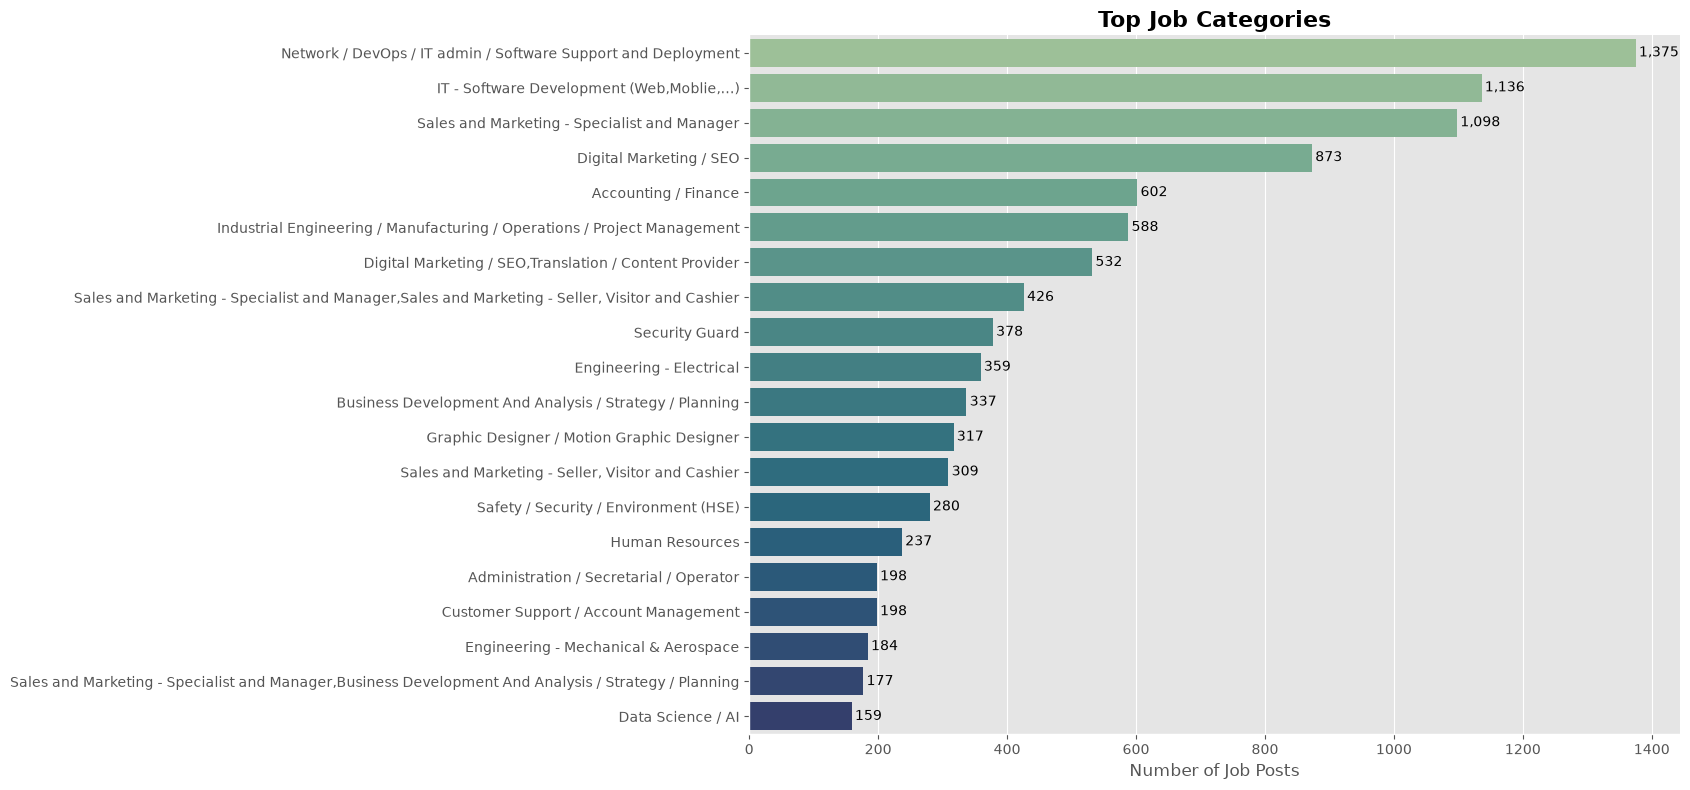

In [108]:
category_counts = (df["category"].fillna("Unknown").value_counts())
plt.figure(figsize=(17, 8))
ax = sns.barplot(x=category_counts[:20].values, y=category_counts[:20].index, hue=category_counts[:20].index, legend=False, palette="crest")
plt.title("Top Job Categories", fontsize=16, weight="bold")
plt.xlabel("Number of Job Posts")
plt.ylabel("")
for i, value in enumerate(category_counts.head(20).values):
    ax.text(value + 5, i, f"{value:,}", va="center")
sns.despine()
plt.tight_layout(); plt.show()

In [109]:
category_share = (df["category"].fillna("Unknown").value_counts(normalize=True).mul(100))
print(f"Top 5 categories represent" f"{category_share.head(5).sum():.2f}% of all jobs.")
print(f"Top 10 categories represent" f"{category_share.head(10).sum():.2f}% of all jobs.")

Top 5 categories represent40.22% of all jobs.
Top 10 categories represent58.28% of all jobs.


## Industry Analysis

This section explores the distribution of job postings across different industries to identify which sectors contribute the most to hiring activity.

In [110]:
df["industries"].head()

0                                                   Transportation / Logistics
1                   Internet Provider / E-commerce / Online Services,Insurance
2    IT / Software / Hardware,Internet Provider / E-commerce / Online Services
3                                                                    Insurance
4    IT / Software / Hardware,Internet Provider / E-commerce / Online Services
Name: industries, dtype: str

In [111]:
industry = (df["industries"].fillna("Unknown").str.split(",").explode().str.strip())
industry.head()

0                          Transportation / Logistics
1    Internet Provider / E-commerce / Online Services
1                                           Insurance
2                            IT / Software / Hardware
2    Internet Provider / E-commerce / Online Services
Name: industries, dtype: str

In [112]:
industry_counts = (industry.value_counts())
industry_counts[:20]

industries
Manufacturing & Production                               2863
IT / Software / Hardware                                 2709
Internet Provider / E-commerce / Online Services         1791
Trading / International Affairs                          1391
Consumer Goods / FMCG                                    1030
Engineering Services / Technical Services & Solutions     979
Retail / Shopping center / Store                          819
Finance / Investment                                      665
Automotive                                                652
Oil & Gas / Petrochemical                                 503
Pharmaceutical                                            475
Education / Research                                      454
Construction / Building Materials & Equipment             448
Consumer Electonics / Home Appliances                     437
Marketing / Advertising                                   420
Banking                                                   4

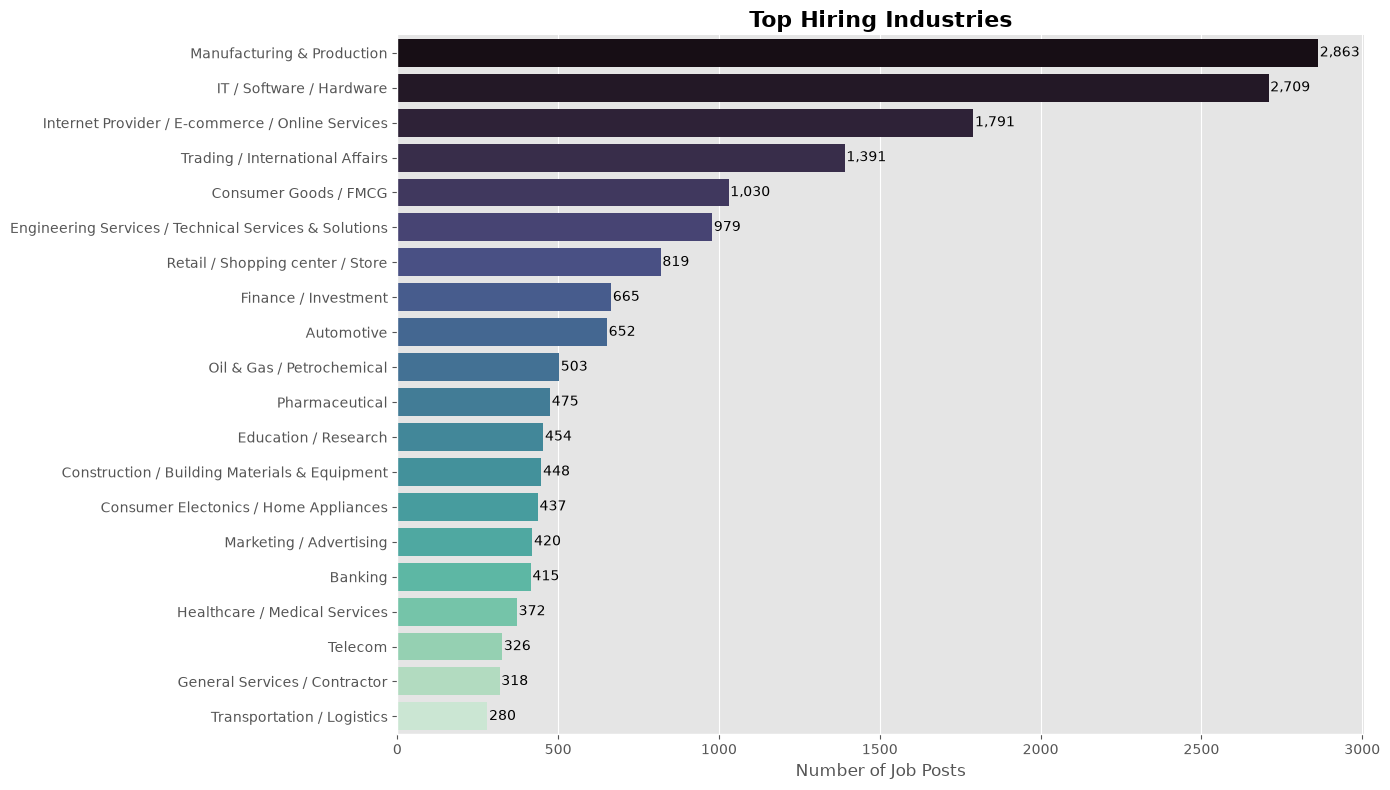

In [113]:
plt.figure(figsize=(14,8))
ax = sns.barplot(x=industry_counts[:20].values, y=industry_counts[:20].index, hue=industry_counts[:20].index, legend=False, palette="mako")
plt.title("Top Hiring Industries", fontsize=16, weight="bold")
plt.xlabel("Number of Job Posts")
plt.ylabel("")
for i, value in enumerate(industry_counts[:20].values):
    ax.text(value + 5, i, f"{value:,}", va="center")
sns.despine(); plt.tight_layout(); plt.show()

In [114]:
industry_share = (industry.value_counts(normalize=True).mul(100).round(2))
industry_share[:15]

industries
Manufacturing & Production                               14.07
IT / Software / Hardware                                 13.32
Internet Provider / E-commerce / Online Services          8.80
Trading / International Affairs                           6.84
Consumer Goods / FMCG                                     5.06
Engineering Services / Technical Services & Solutions     4.81
Retail / Shopping center / Store                          4.03
Finance / Investment                                      3.27
Automotive                                                3.21
Oil & Gas / Petrochemical                                 2.47
Pharmaceutical                                            2.33
Education / Research                                      2.23
Construction / Building Materials & Equipment             2.20
Consumer Electonics / Home Appliances                     2.15
Marketing / Advertising                                   2.06
Name: proportion, dtype: float64

In [115]:
print(f"Top 5 industries account for {industry_share.head(5).sum():.2f}% of all industry mentions.")
print(f"Top 10 industries account for {industry_share.head(10).sum():.2f}% of all industry mentions.")

Top 5 industries account for 48.09% of all industry mentions.
Top 10 industries account for 65.88% of all industry mentions.


## Work Type Analysis
Employment type is one of the most important characteristics of a job market.
This analysis examines the distribution of work arrangements to understand whether employers primarily seek full-time employees or offer more flexible work options such as part-time, project-based, contract, or internship positions.

In [116]:
df["work_type"].value_counts(dropna=False)

work_type
Full Time                 11087
Full Time Or Part Time      715
Part Time                   443
Project - based             391
NaN                           4
Name: count, dtype: int64

In [117]:
work_type_dist = (df["work_type"].fillna("Unknown").value_counts().rename_axis("Work Type").reset_index(name="Count"))
work_type_dist["Percentage"] = (work_type_dist["Count"] / work_type_dist["Count"].sum() * 100).round(2)
work_type_dist
# The Iranian job market is heavily dominated by full-time employment opportunities, indicating that employers
# generally prioritize long-term workforce recruitment over flexible work arrangements. Project-based and internship
# positions represent only a small fraction of the market, suggesting limited entry points for students and freelancers.

,Work Type,Count,Percentage
0,Full Time,11087,87.71
1,Full Time Or Part Time,715,5.66
2,Part Time,443,3.50
3,Project - based,391,3.09
4,Unknown,4,0.03


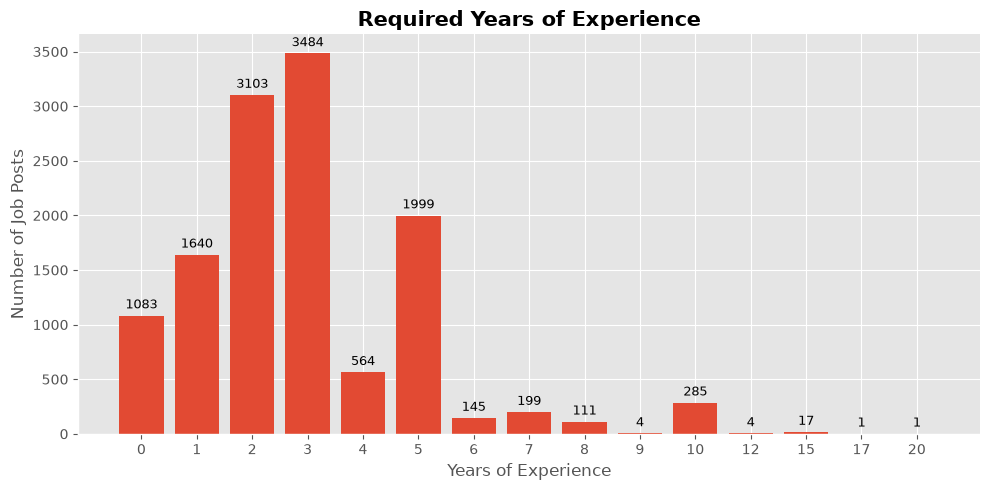

In [118]:
experience_dist = (df["experience_years"].value_counts().sort_index())
fig, ax = plt.subplots(figsize=(10,5))
bars = ax.bar(experience_dist.index.astype(str), experience_dist.values)
ax.bar_label(bars, padding=3, fontsize=9)
ax.set_title("Required Years of Experience", fontsize=15, weight="bold")
ax.set_xlabel("Years of Experience")
ax.set_ylabel("Number of Job Posts")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout(); plt.show()

In [119]:
experience_group = pd.cut(
    df["experience_years"],
    bins=[-1,0,2,5,100],
    labels=[
        "No Experience",
        "Junior (1–2)",
        "Mid-Level (3–5)",
        "Senior (6+)"
    ]
)
experience_group.value_counts()

experience_years
Mid-Level (3–5)    6047
Junior (1–2)       4743
No Experience      1083
Senior (6+)         767
Name: count, dtype: int64

# **Company Landscape**

### Is the Iranian job market dominated by a small number of companies, or is hiring distributed across many employers?

In [120]:
company_stats = pd.Series({
    "Total Companies": df["company"].nunique(),
    "Total Job Posts": len(df),
    "Average Jobs per Company": round(len(df) / df["company"].nunique(), 2)
})
company_stats.to_frame("Value")

,Value
Total Companies,6071.00
Total Job Posts,12640.00
Average Jobs per Company,2.08


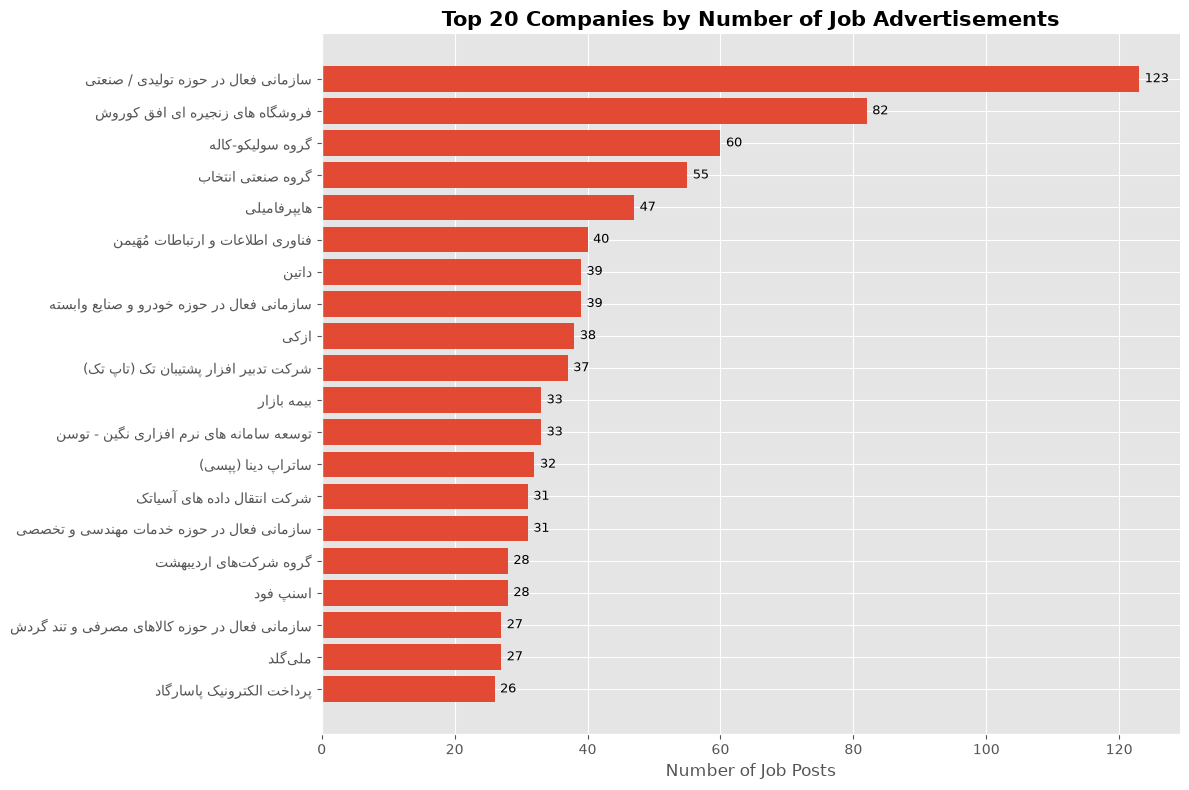

In [121]:
top_companies = (df["company"].fillna("Unknown").value_counts()[:20].sort_values())
fig, ax = plt.subplots(figsize=(12,8))
bars = ax.barh(top_companies.index, top_companies.values)
ax.bar_label(bars, padding=4, fontsize=9)
ax.set_title("Top 20 Companies by Number of Job Advertisements", fontsize=15, fontweight="bold")
ax.set_xlabel("Number of Job Posts")
ax.set_ylabel("")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()

In [122]:
top10_share = (df["company"].value_counts()[:10].sum() / len(df) * 100)
print(f"Top 10 companies account for {top10_share:.2f}% of all job advertisements.")

Top 10 companies account for 4.43% of all job advertisements.


# **Geographic Landscape**

### How geographically concentrated is the Iranian job market?

In [123]:
province_dist = (df["province"].fillna("Unknown").value_counts().rename_axis("Province").reset_index(name="Job Posts"))
province_dist["Share (%)"] = (province_dist["Job Posts"] / province_dist["Job Posts"].sum() * 100).round(2)
province_dist[:15]

,Province,Job Posts,Share (%)
0,تهران,8293,65.61
1,اصفهان,715,5.66
2,البرز,598,4.73
3,خراسان رضوی,577,4.56
4,مازندران,338,2.67
5,فارس,243,1.92
6,قم,217,1.72
7,گیلان,165,1.31
8,کرمان,162,1.28
9,خوزستان,161,1.27


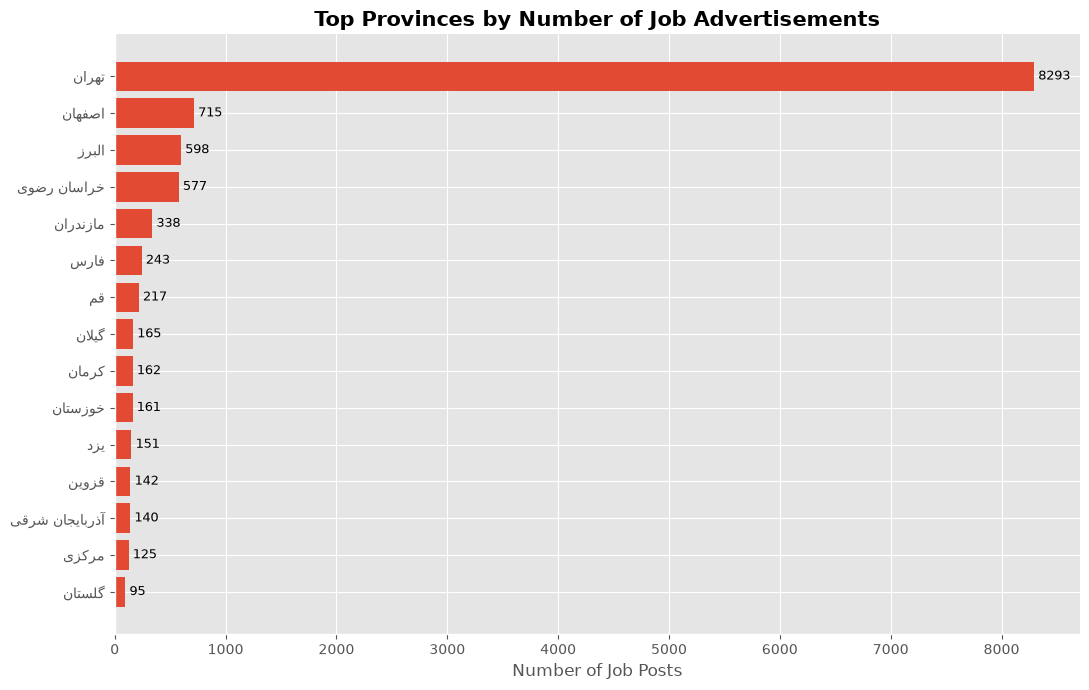

In [124]:
top_provinces = province_dist[:15].sort_values("Job Posts")
fig, ax = plt.subplots(figsize=(11,7))
bars = ax.barh(top_provinces["Province"], top_provinces["Job Posts"])
ax.bar_label(bars, padding=3, fontsize=9)
ax.set_title( "Top Provinces by Number of Job Advertisements", fontsize=15, fontweight="bold")
ax.set_xlabel("Number of Job Posts")
ax.set_ylabel("")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()

In [125]:
top5_share = (province_dist.head(5)["Job Posts"].sum() / len(df) * 100)
print(f"Top 5 provinces account for {top5_share:.2f}% of all job advertisements.")

Top 5 provinces account for 83.24% of all job advertisements.


In [126]:
city_dist = (df["city"].fillna("Unknown").value_counts()[:20])
city_dist

city
تهران      7572
اصفهان      577
مشهد        538
کرج         350
شیراز       229
قم          209
یزد         131
رشت         123
پردیس       121
تبریز       121
کرمان       118
اهواز       105
ساری         81
قزوین        77
شهر قدس      71
بابل         71
آمل          61
پاکدشت       59
گرگان        57
ساوه         56
Name: count, dtype: int64

In [127]:
remote_dist = (df["remote"].fillna(False).value_counts().rename_axis("Remote").reset_index(name="Job Posts"))
remote_dist["Percentage"] = ( remote_dist["Job Posts"] / remote_dist["Job Posts"].sum() * 100).round(2)
remote_dist

,Remote,Job Posts,Percentage
0,False,11934,94.41
1,True,706,5.59


In [128]:
province_remote = (df.groupby("province")["remote"].mean().mul(100).sort_values(ascending=False))
province_remote[:20]

province
خراسان جنوبی          41.666667
چهارمحال و بختیاری    22.222222
اردبیل                18.181818
کرمانشاه               9.090909
فارس                   8.085106
مازندران               7.861635
همدان                  7.692308
اصفهان                 7.624633
خراسان رضوی            7.622505
خوزستان                7.096774
آذربایجان شرقی         6.716418
گلستان                 6.593407
کرمان                  5.960265
تهران                  5.601318
لرستان                      5.0
گیلان                  4.968944
قم                     4.878049
یزد                    4.225352
بوشهر                  3.636364
سمنان                  3.571429
Name: remote, dtype: object

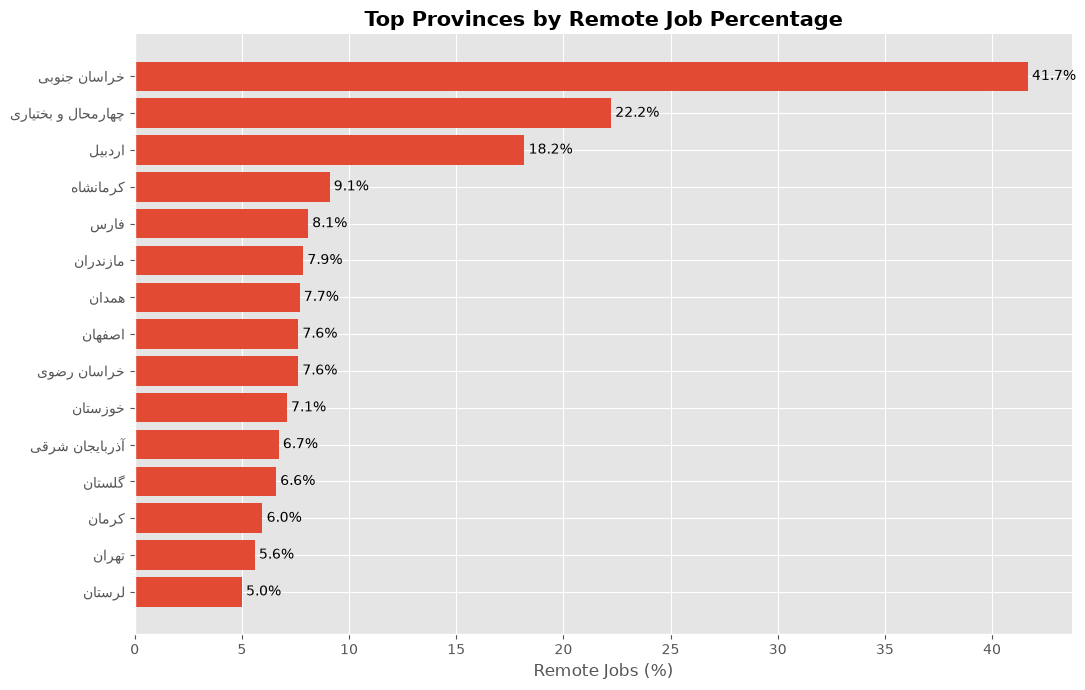

In [129]:
fig, ax = plt.subplots(figsize=(11,7))
bars = ax.barh(province_remote.head(15).sort_values().index, province_remote.head(15).sort_values().values)
ax.bar_label(bars, fmt="%.1f%%", padding=3)
ax.set_title("Top Provinces by Remote Job Percentage", fontsize=15, weight="bold")
ax.set_xlabel("Remote Jobs (%)")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()

In [130]:
df.groupby("province").agg(total_jobs=("job_id","count"), remote_jobs=("remote","sum"))

,total_jobs,remote_jobs
province,,
آذربایجان شرقی,140,9
آذربایجان غربی,32,1
اردبیل,33,6
اصفهان,715,52
البرز,598,17
ایلام,10,0
بوشهر,57,2
تهران,8293,442
خراسان جنوبی,12,5


In [131]:
remote_city = (df[df["remote"] == True]["city"].value_counts()[:15])
onsite_city = (df[df["remote"] == False]["city"].value_counts()[:15])
display(remote_city)
display(onsite_city)

city
تهران        428
اصفهان        42
مشهد          42
شیراز         18
خارج کشور     15
کرج           15
ساری          14
قم            10
تبریز          8
کرمان          7
اهواز          7
اردبیل         6
رشت            6
کاشان          5
بیرجند         5
Name: count, dtype: int64

city
تهران      6767
اصفهان      513
مشهد        472
کرج         312
شیراز       204
قم          187
یزد         119
رشت         113
پردیس       110
تبریز       110
کرمان       103
اهواز        94
شهر قدس      68
قزوین        68
بابل         63
Name: count, dtype: int64

# **Skill Market Analysis**

## Skill Coverage
How many job postings explicitly mention technical skills?

In [132]:
skill_available = (df["software"].notna().mean() * 100)
print(f"{skill_available:.2f}% of job advertisements specify software requirements.")

coverage = pd.DataFrame({"Has Skills": [df["software"].notna().sum(), df["software"].isna().sum()]}, index=["Yes","No"])
coverage

70.91% of job advertisements specify software requirements.


,Has Skills
Yes,8963
No,3677


## Most Demanded Skills

In [133]:
skills = (df["software"].dropna().str.split(",").explode().str.strip())
skills.head()

0             Python
0    Oracle Database
0                GIT
1             Python
1         PostgreSql
Name: software, dtype: str

In [134]:
top_skills = (skills.value_counts().head(25))
top_skills

software
Microsoft Excel          4468
Microsoft Word           3061
Adobe Photoshop           913
Microsoft Powerpoint      772
GIT                       696
Sql Server                691
Python                    554
PowerBI                   537
Linux                     530
Adobe Premiere            519
Google Analytics          498
Docker                    459
Adobe Illustrator         428
Wordpress                 416
Rest API                  407
Microsoft Outlook         396
JavaScript                393
After Effects             384
Windows Server            373
Google Search Console     361
راهکاران                  356
Html & CSS                339
AutoCad                   332
Microsoft Project         300
Active Directory          277
Name: count, dtype: int64

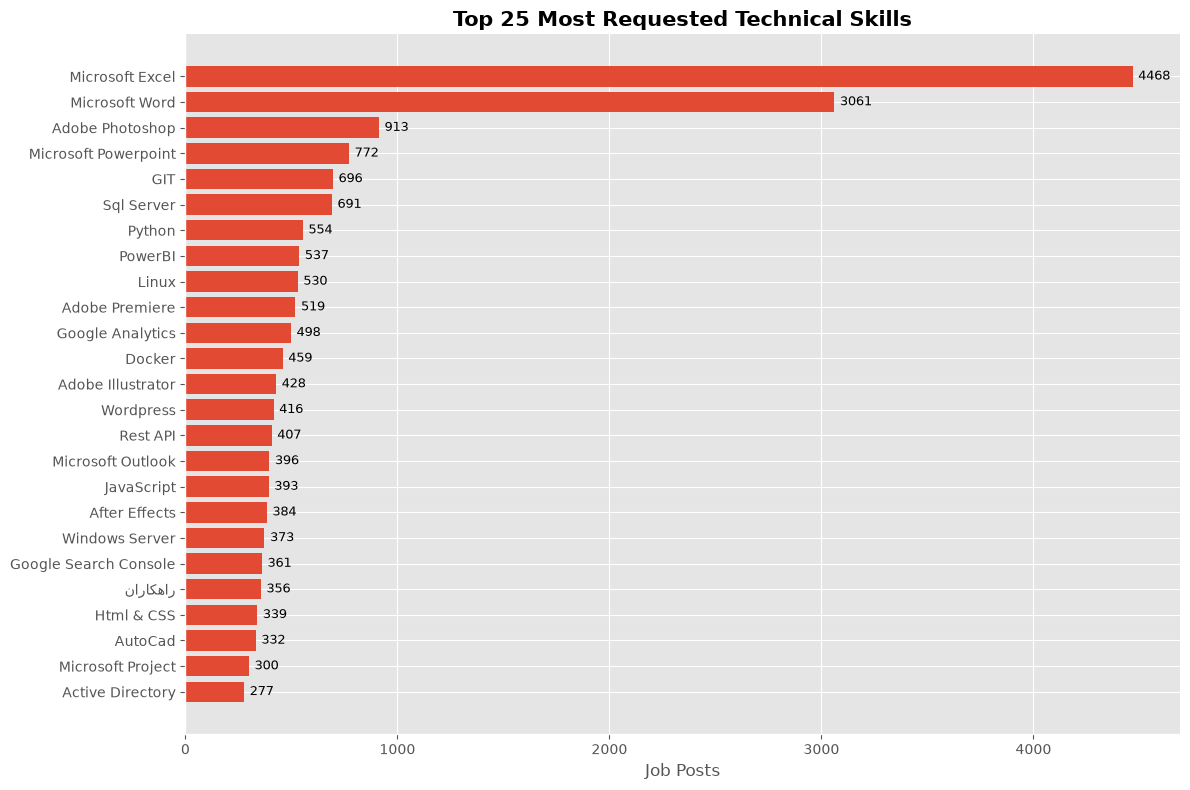

In [135]:
fig, ax = plt.subplots(figsize=(12,8))
bars = ax.barh(top_skills.sort_values().index, top_skills.sort_values().values)
ax.bar_label(bars, padding=4, fontsize=9)
ax.set_title("Top 25 Most Requested Technical Skills", fontsize=15, fontweight="bold")
ax.set_xlabel("Job Posts")
ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
plt.tight_layout(); plt.show()

## Average Skill Count

In [136]:
skill_count = (df["software"].fillna("").str.split(",").apply(lambda x: len([i for i in x if i.strip()])))
skill_count.describe()

count    12640.000000
mean         2.312421
std          2.250427
min          0.000000
25%          0.000000
50%          2.000000
75%          3.000000
max         20.000000
Name: software, dtype: float64

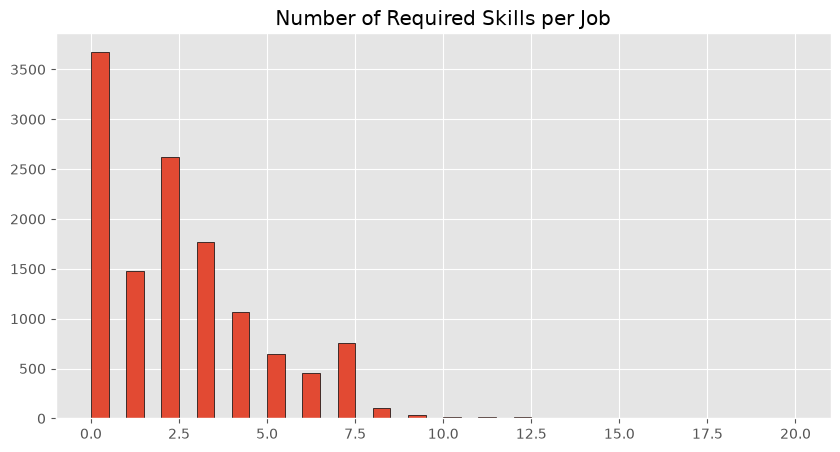

In [137]:
fig, ax = plt.subplots(figsize=(10,5))
ax.hist(skill_count, bins=40, edgecolor="black")
ax.set_title("Number of Required Skills per Job")
plt.show()

## Skill Co-occurrence Analysis
Which technical skills are commonly required together in the Iranian job market?

In [138]:
df_it = df.copy()

# 1. Define IT / Software keywords
it_keywords = [
    # Software Engineering
    "developer",
    "programmer",
    "software engineer",
    "software developer",
    "backend",
    "frontend",
    "full stack",

    # Programming Languages
    "python",
    "java",
    "javascript",
    "typescript",
    "php",
    "kotlin",
    "swift",
    "c#",
    ".net",

    # Frameworks
    "django",
    "flask",
    "fastapi",
    "spring",
    "react",
    "angular",
    "vue",
    "node",

    # Data / AI
    "data",
    "machine learning",
    "artificial intelligence",
    "deep learning",

    # DevOps
    "devops",
    "docker",
    "kubernetes",
    "cloud",
    "linux",

    # Database
    "sql",
    "mysql",
    "postgresql",
    "mongodb",
    "oracle",

    # Persian
    "برنامه نویس",
    "توسعه دهنده",
    "مهندس نرم افزار",
    "برنامه نویسی",
    "بک اند",
    "فرانت اند",
]

In [139]:
pattern = "|".join(it_keywords)

df_it = df_it[
    df_it["keyword"].astype(str).str.lower().str.contains(pattern, na=False)
    |
    df_it["title"].astype(str).str.lower().str.contains(pattern, na=False)
]

print("Total jobs:", len(df))
print("IT jobs:", len(df_it))

Total jobs: 12640
IT jobs: 8334


In [140]:
skills_df = (df_it[["job_id", "software"]].dropna().copy())
print(len(skills_df))

6689


In [141]:
skills_df["software"] = skills_df["software"].apply(
    lambda x: [
        skill.strip().lower()
        for skill in x.split(",")
        if skill.strip()
    ]
)

In [142]:
technical_skills = {
    "python",
    "java",
    "javascript",
    "typescript",
    "php",
    "c#",
    ".net",

    "django",
    "flask",
    "fastapi",
    "spring",
    "react",
    "angular",
    "vue",
    "node",

    "docker",
    "kubernetes",
    "linux",
    "git",

    "sql",
    "mysql",
    "postgresql",
    "mongodb",
    "oracle",

    "redis",
    "rabbitmq",

    "rest api",
    "unit testing",

    "machine learning",
    "deep learning",
    "tensorflow",
    "pytorch",

    "spark",
    "airflow"
}

In [143]:
skills_df["software"] = skills_df["software"].apply(lambda skills: [skill for skill in skills if skill in technical_skills])

In [144]:
skills_df = skills_df[skills_df["software"].apply(len) > 0]

In [145]:
from itertools import combinations
from collections import Counter


skill_pairs = []

for skills in skills_df["software"]:

    skills = set(skills)

    if len(skills) < 2:
        continue

    skill_pairs.extend(
        combinations(sorted(skills), 2)
    )


pair_df = (
    pd.DataFrame(
        Counter(skill_pairs).items(),
        columns=["Skill Pair", "Frequency"]
    )
    .sort_values(
        "Frequency",
        ascending=False
    )
)


pair_df.head(20)

,Skill Pair,Frequency
43,"(docker, git)",246
23,"(git, rest api)",244
71,"(git, javascript)",212
54,"(docker, linux)",171
3,"(docker, python)",158
1,"(docker, kubernetes)",154
0,"(git, python)",153
76,"(git, react)",148
120,"(git, typescript)",146
27,"(linux, python)",141


## Skill Network Graph


In [146]:
import networkx as nx

G = nx.Graph()

for _, row in pair_df.head(50).iterrows():
    skill1, skill2 = row["Skill Pair"]
    G.add_edge(skill1, skill2, weight=row["Frequency"])

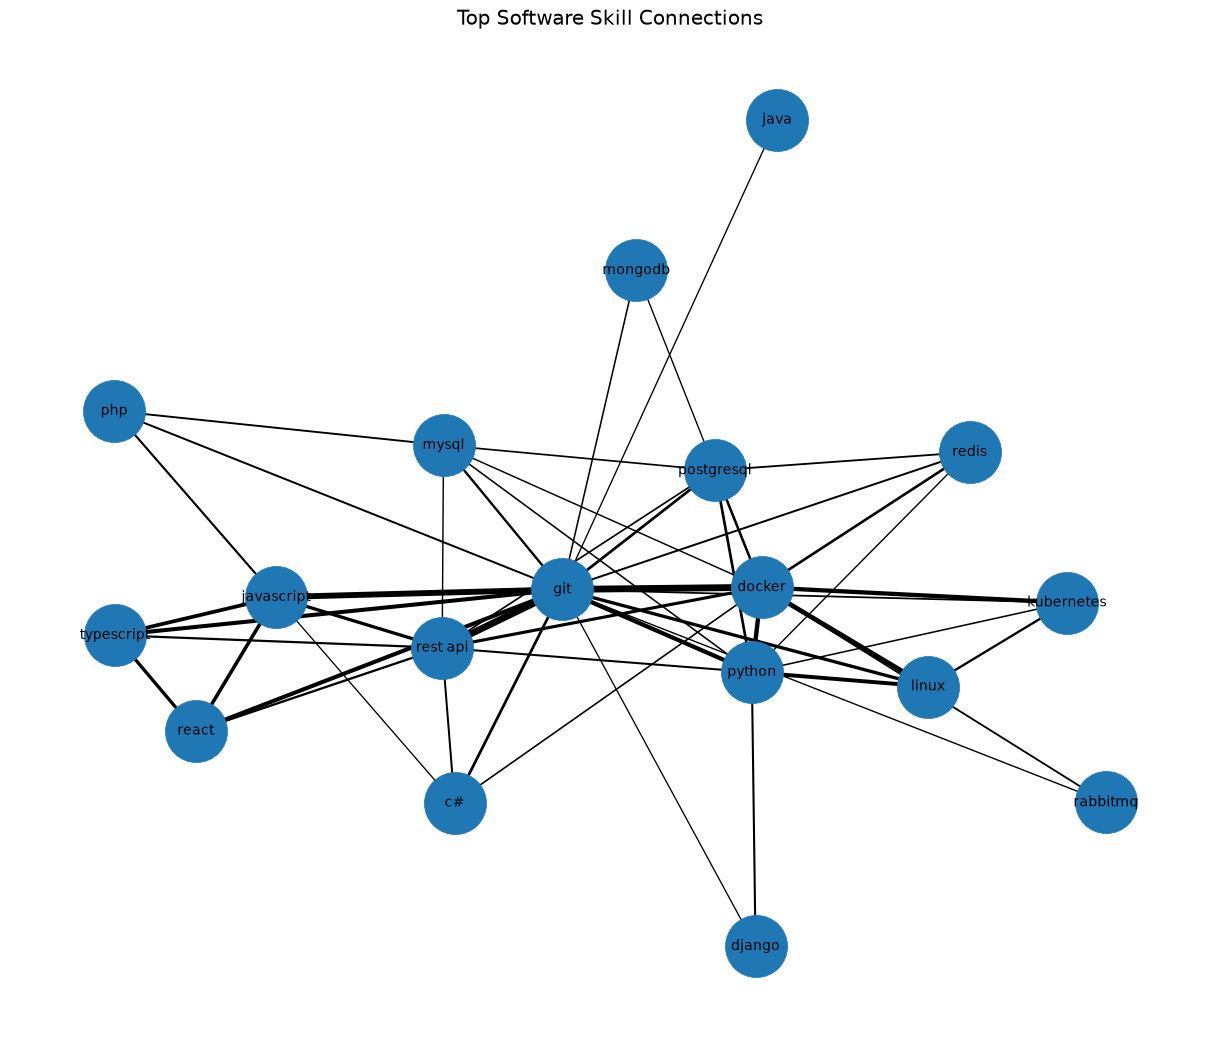

In [147]:
plt.figure(figsize=(12, 10))
pos = nx.spring_layout(G, k=0.8, seed=42)

nx.draw(G, pos, with_labels=True, node_size=2000, font_size=10, width=[G[u][v]["weight"] / 50 for u, v in G.edges()])

plt.title("Top Software Skill Connections"); plt.show()

In [148]:
skills_df = (df[["job_id", "software"]].dropna().copy())

skills_df["skill"] = (skills_df["software"].str.split(","))

skills_df = (skills_df.explode("skill"))

skills_df["skill"] = (skills_df["skill"].str.strip())

skills_df.head()

,job_id,software,skill
0,1396130,"Python,Oracle Database,GIT",Python
0,1396130,"Python,Oracle Database,GIT",Oracle Database
0,1396130,"Python,Oracle Database,GIT",GIT
1,1401623,"Python,PostgreSql,Prometheus,Gerafana,Docker,Redis,Kubernetes",Python
1,1401623,"Python,PostgreSql,Prometheus,Gerafana,Docker,Redis,Kubernetes",PostgreSql


In [149]:
skills_df["skill_clean"] = (skills_df["skill"].str.lower())
skills_df.head()

,job_id,software,skill,skill_clean
0,1396130,"Python,Oracle Database,GIT",Python,python
0,1396130,"Python,Oracle Database,GIT",Oracle Database,oracle database
0,1396130,"Python,Oracle Database,GIT",GIT,git
1,1401623,"Python,PostgreSql,Prometheus,Gerafana,Docker,Redis,Kubernetes",Python,python
1,1401623,"Python,PostgreSql,Prometheus,Gerafana,Docker,Redis,Kubernetes",PostgreSql,postgresql


In [150]:
skills_df = (skills_df[skills_df["skill_clean"] != ""])
skills_df.shape

(29229, 4)

In [151]:
skill_per_job = (skills_df.groupby("job_id")["skill_clean"].count())
skill_per_job.describe()

count    8963.000000
mean        3.261073
std         2.012045
min         1.000000
25%         2.000000
50%         3.000000
75%         4.000000
max        20.000000
Name: skill_clean, dtype: float64

In [152]:
from itertools import combinations


skill_pairs = []


for skills in (skills_df.groupby("job_id")["skill_clean"]):
    job_skills = sorted(set(skills[1]))
    if len(job_skills) < 2:
        continue
    pairs = combinations(job_skills, 2)
    skill_pairs.extend(pairs)

pairs_df = pd.DataFrame(skill_pairs, columns=["skill_1", "skill_2"])
pairs_df.head()

,skill_1,skill_2
0,docker,gitlab
1,docker,kubernetes
2,docker,linux
3,docker,prometheus
4,gitlab,kubernetes


In [153]:
pair_frequency = (pairs_df.value_counts().reset_index())
pair_frequency.columns = ["skill_1", "skill_2", "frequency"]
pair_frequency.head(20)

,skill_1,skill_2,frequency
0,microsoft excel,microsoft word,3038
1,microsoft excel,microsoft powerpoint,755
2,microsoft powerpoint,microsoft word,678
3,microsoft excel,powerbi,425
4,adobe photoshop,adobe premiere,420
5,adobe illustrator,adobe photoshop,410
6,microsoft excel,microsoft outlook,386
7,microsoft outlook,microsoft word,354
8,adobe premiere,after effects,338
9,google analytics,google search console,327


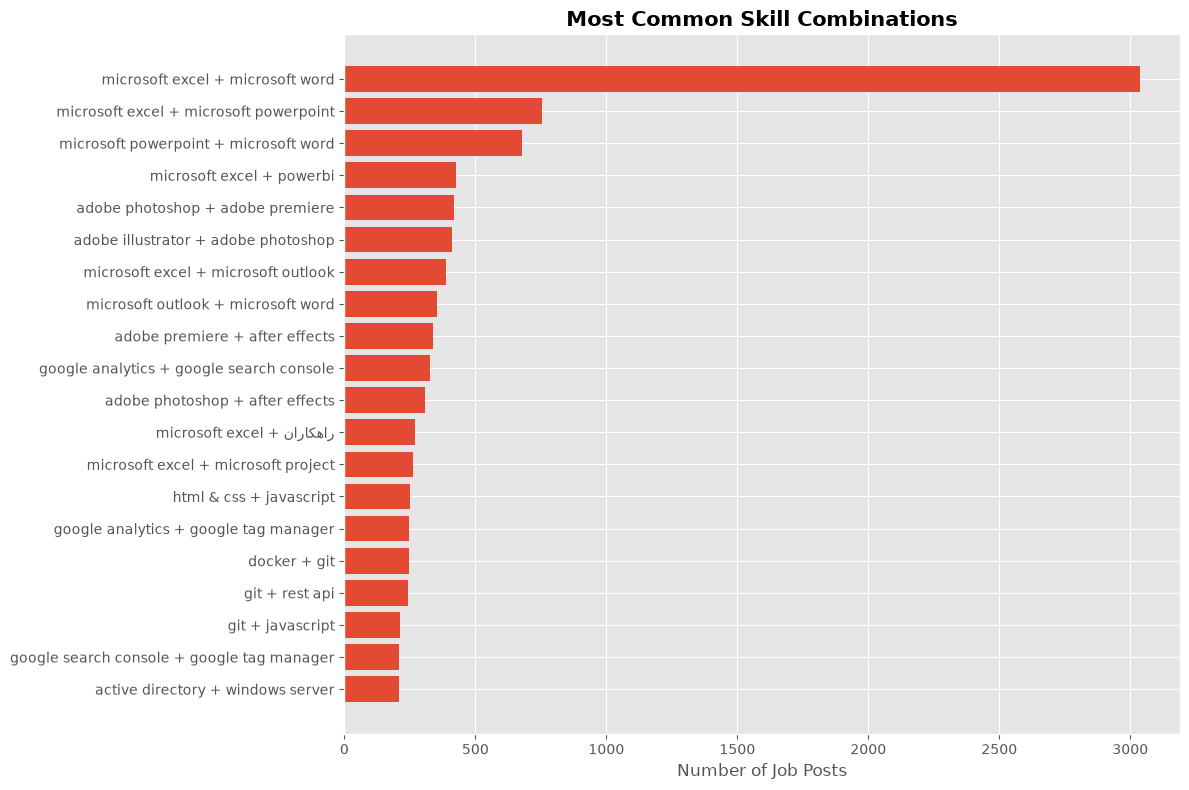

In [154]:
top_pairs = (pair_frequency[:20].copy())
top_pairs["pair"] = (top_pairs["skill_1"] + " + " + top_pairs["skill_2"])
top_pairs = (top_pairs.sort_values("frequency"))

plt.figure(figsize=(12,8))
plt.barh(top_pairs["pair"], top_pairs["frequency"])
plt.title("Most Common Skill Combinations", fontsize=15, weight="bold")
plt.xlabel("Number of Job Posts")
plt.tight_layout()
plt.show()

# **Salary Analysis**

In [155]:
# Salary Coverage
df["salary_visible"].value_counts(normalize=True)

salary_visible
False    0.661392
True     0.338608
Name: proportion, dtype: float64

In [156]:
#Salary Distribution
df[["salary_min","salary_max"]].describe()

,salary_min,salary_max
count,4280.000000,4280.000000
mean,37.976869,52.509112
std,21.778467,29.833015
min,3.000000,4.000000
25%,25.000000,35.000000
50%,30.000000,45.000000
75%,45.000000,60.000000
max,300.000000,400.000000


In [157]:
df.groupby("experience_years")[["salary_min","salary_max"]].median()

,salary_min,salary_max
experience_years,,
0,25.0,35.0
1,25.0,35.0
2,30.0,40.0
3,35.0,45.0
4,38.5,50.0
5,45.0,60.0
6,53.5,70.0
7,55.0,71.0
8,63.5,100.0


In [158]:
salary_category = (df.groupby("category")["salary_max"].median().sort_values(ascending=False))
salary_category.head(20)

category
Sales and Marketing - Specialist and Manager,CEO / Business Head / Factory Manager                                              200.0
Purchasing / Procurement,CEO / Business Head / Factory Manager                                                                  200.0
Business Development And Analysis / Strategy / Planning,CEO / Business Head / Factory Manager                                   150.0
Sales and Marketing - Specialist and Manager,Digital Marketing / SEO,Business Development And Analysis / Strategy / Planning    150.0
Industrial Engineering / Manufacturing / Operations / Project Management,CEO / Business Head / Factory Manager                  150.0
CEO / Business Head / Factory Manager,Mining Engineering & Geology                                                              150.0
CEO / Business Head / Factory Manager                                                                                           150.0
Commercial Affairs / Trading,CEO / Business Head / Fa

In [159]:
df.groupby("remote")[["salary_min","salary_max"]].median()

,salary_min,salary_max
remote,,
False,31.0,45.0
True,30.0,40.0


In [160]:
salary_df = df[df["salary_min"].notna()].copy()
print(f"Salary available jobs: {len(salary_df)} / {len(df)} ({len(salary_df) / len(df) * 100:.2f}%)")

Salary available jobs: 4280 / 12640 (33.86%)


In [161]:
salary_df[["salary_min", "salary_max"]].median()

salary_min    30.0
salary_max    45.0
dtype: float64

In [162]:
salary_df.sort_values("salary_max", ascending=False)[["title", "company", "salary_min", "salary_max"]][:20]

,title,company,salary_min,salary_max
8464,مشاور فروش املاک,املاک غلامی,267.0,400.0
7761,Head of Growth & Marketing - خانم,مرکز بیزینس کوچینگ ایران,267.0,400.0
248,Senior Data Manager,یوزرآوا,300.0,350.0
9757,Senior Marketing Manager,یوزرآوا,280.0,300.0
6508,مدیر فروش و بازاریابی - آقا,پیشگامان انرژی نورا تِک,180.0,250.0
3267,مدیر مالی,سازمانی فعال در حوزه دارو,200.0,250.0
3298,مدیر مالی,سازمانی فعال در حوزه فناوری اطلاعات / نرم افزار و سخت افزار,200.0,250.0
11034,مدیر فروش,شرکت سرام پخش سورن,200.0,250.0
855,مدیر ارشد فناوری,اهلال سان,200.0,250.0
4433,Senior SEO Manager,یوزرآوا,200.0,230.0


In [163]:
salary_df["salary_avg"] = (salary_df["salary_min"] + salary_df["salary_max"]) / 2
salary_df["salary_avg"].quantile([0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99])

0.01     17.50
0.05     22.50
0.25     30.00
0.50     37.50
0.75     52.50
0.95     90.00
0.99    140.42
Name: salary_avg, dtype: float64

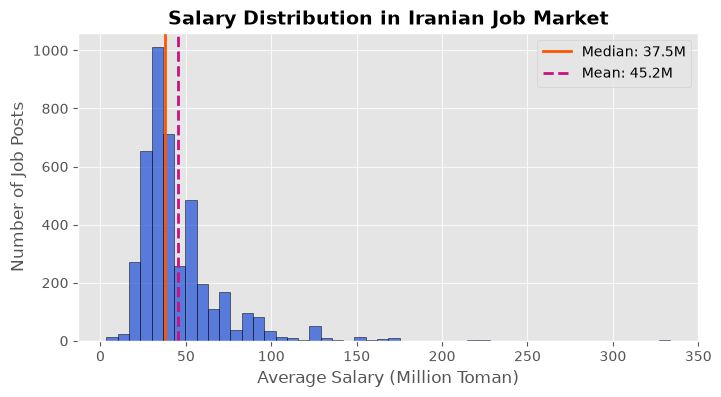

In [164]:
plt.figure(figsize=(8,4))
plt.hist(salary_df["salary_avg"], bins=50, edgecolor="black", color="#1D4ED8", alpha=0.7)
plt.axvline(salary_df["salary_avg"].median(),color="#FF5500" , linestyle="-", linewidth=2, label=f"Median: {salary_df['salary_avg'].median():.1f}M")
plt.axvline(salary_df["salary_avg"].mean(),color="#CA1083", linestyle="--", linewidth=2, label=f"Mean: {salary_df['salary_avg'].mean():.1f}M")
plt.title("Salary Distribution in Iranian Job Market", fontsize=14, fontweight="bold")
plt.xlabel("Average Salary (Million Toman)")
plt.ylabel("Number of Job Posts")
plt.legend()
plt.grid(alpha=0.8)
plt.show()

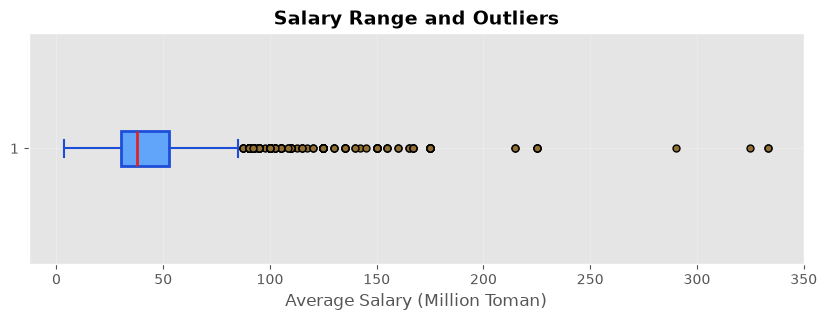

In [165]:
plt.figure(figsize=(10,3))

plt.boxplot(
    salary_df["salary_avg"],
    vert=False,
    patch_artist=True,

    boxprops=dict(
        facecolor="#60A5FA",
        color="#1D4ED8",
        linewidth=2
    ),

    medianprops=dict(
        color="#DC2626",
        linewidth=2
    ),

    whiskerprops=dict(
        color="#1D4ED8",
        linewidth=1.5
    ),

    capprops=dict(
        color="#1D4ED8",
        linewidth=1.5
    ),

    flierprops=dict(
        marker="o",
        markerfacecolor="#916E31",
        markeredgecolor="#000000",
        markersize=5,
        linestyle="none"
    )
)

plt.title("Salary Range and Outliers", fontsize=14, fontweight="bold")
plt.xlabel("Average Salary (Million Toman)")
plt.grid(alpha=0.25); plt.show()

### Salary vs Experience Analysis

In [166]:
salary_exp_df = salary_df[salary_df["experience_years"].notna()].copy()
experience_distribution = (salary_exp_df["experience_years"].value_counts().sort_index())
experience_distribution

experience_years
0      416
1      590
2     1124
3     1133
4      194
5      600
6       38
7       44
8       40
10      91
12       3
15       6
20       1
Name: count, dtype: int64

In [167]:
salary_by_experience = (salary_exp_df
.groupby("experience_years")
    ["salary_avg"]
    .agg(
        count="count",
        median_salary="median",
        mean_salary="mean"
    )
    .reset_index()
)
salary_by_experience

,experience_years,count,median_salary,mean_salary
0,0,416,29.50,32.263221
1,1,590,30.00,33.973729
2,2,1124,35.00,38.610765
3,3,1133,40.00,44.673433
4,4,194,45.00,52.394330
5,5,600,55.00,60.991667
6,6,38,61.25,72.250000
7,7,44,63.75,83.886364
8,8,40,81.75,84.250000
9,10,91,85.00,94.115385


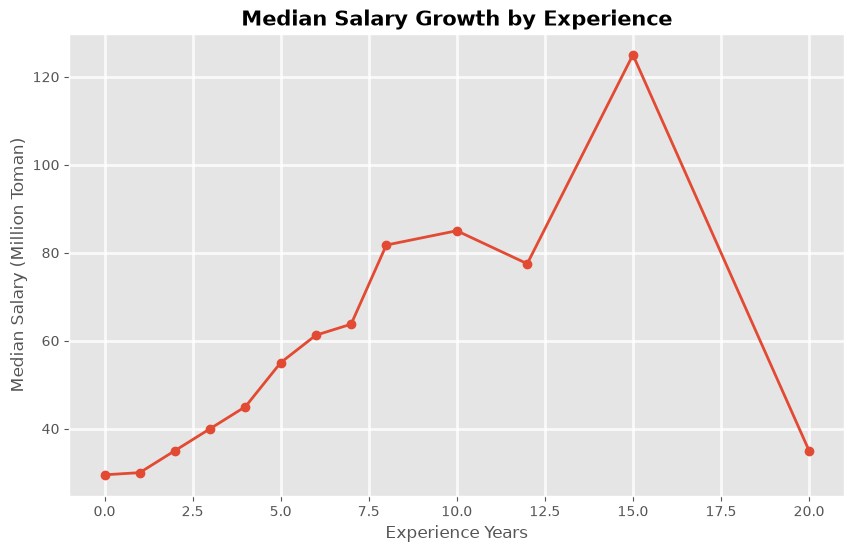

In [168]:
plt.figure(figsize=(10,6))
plt.plot(salary_by_experience["experience_years"], salary_by_experience["median_salary"], marker="o", linewidth=2, markersize=6)
plt.title("Median Salary Growth by Experience", fontsize=15, fontweight="bold")
plt.xlabel("Experience Years")
plt.ylabel("Median Salary (Million Toman)")
plt.grid(alpha=0.8, linestyle="-", linewidth=2); plt.show()

In [169]:
salary_by_experience

,experience_years,count,median_salary,mean_salary
0,0,416,29.50,32.263221
1,1,590,30.00,33.973729
2,2,1124,35.00,38.610765
3,3,1133,40.00,44.673433
4,4,194,45.00,52.394330
5,5,600,55.00,60.991667
6,6,38,61.25,72.250000
7,7,44,63.75,83.886364
8,8,40,81.75,84.250000
9,10,91,85.00,94.115385


In [170]:
def experience_level(years):
    if years <= 1:
        return "Junior"
    elif years <= 3:
        return "Mid-Level"
    elif years <= 5:
        return "Senior"
    else:
        return "Expert"

salary_exp_df["experience_level"] = (salary_exp_df["experience_years"].apply(experience_level))

In [171]:
salary_exp_df.groupby("experience_level")["salary_avg"].agg(["count","median","mean"])

,count,median,mean
experience_level,,,
Expert,223,80.0,87.000000
Junior,1006,30.0,33.266402
Mid-Level,2257,37.5,41.654187
Senior,794,50.0,58.891058


### Key Findings

- Experience has a strong positive relationship with salary levels in the Iranian job market.
- The largest salary growth occurs during the transition from junior to senior positions.
- Mid-level candidates represent the largest share of salary-reported positions, indicating strong market demand.
- Expert-level positions receive significantly higher compensation, although they represent a smaller portion of job postings.
- Experience alone does not fully explain salary differences; job category, skills, and location should also be considered.

# **Salary by Job Category Analysis**

### Category Salary Dataset

In [172]:
salary_category_df = salary_df[salary_df["category"].notna()].copy()
category_counts = (salary_category_df["category"].value_counts())
category_counts[:20]

category
Digital Marketing / SEO                                                                           431
Sales and Marketing - Specialist and Manager                                                      374
Network / DevOps / IT admin / Software Support and Deployment                                     341
IT - Software Development (Web,Moblie,…)                                                          327
Digital Marketing / SEO,Translation / Content Provider                                            276
Sales and Marketing - Specialist and Manager,Sales and Marketing - Seller, Visitor and Cashier    228
Accounting / Finance                                                                              219
Industrial Engineering / Manufacturing / Operations / Project Management                          163
Sales and Marketing - Seller, Visitor and Cashier                                                 162
Graphic Designer / Motion Graphic Designer                               

In [173]:
salary_by_category = (salary_category_df.groupby("category")["salary_avg"]
.agg(
        count="count",
        median_salary="median",
        mean_salary="mean"
    )
    .reset_index()
)
salary_by_category

,category,count,median_salary,mean_salary
0,Accounting / Finance,219,42.5,53.591324
1,"Accounting / Finance,Administration / Secretarial / Operator",3,30.0,29.833333
2,"Accounting / Finance,Financial Market Trader and Analyst",2,39.0,39.000000
3,Administration / Secretarial / Operator,85,30.0,29.358824
4,"Administration / Secretarial / Operator,Executive Manager",1,25.0,25.000000
...,...,...,...,...
206,Transport / Logistics / Warehousing,40,40.0,44.650000
207,"Transport / Logistics / Warehousing,Accounting / Finance",1,52.5,52.500000
208,"Transport / Logistics / Warehousing,Administration / Secretarial / Operator",1,34.0,34.000000
209,"Transport / Logistics / Warehousing,Engineering - Civil",1,37.5,37.500000


In [174]:
salary_by_category_filtered = (salary_by_category[salary_by_category["count"] >= 20].sort_values("median_salary", ascending=False))
salary_by_category_filtered[:20]

,category,count,median_salary,mean_salary
38,Data Science / AI,38,53.75,63.934211
27,Commercial Affairs / Trading,38,50.00,60.592105
63,Engineering - Electrical,123,50.00,52.890244
60,Engineering - Civil,25,50.00,50.580000
10,Business Development And Analysis / Strategy / Planning,63,50.00,58.444444
101,Industrial Engineering / Manufacturing / Operations / Project Management,163,50.00,54.432515
168,Sales and Marketing - Specialist and Manager,374,50.00,57.429144
91,"IT - Software Development (Web,Moblie,…)",327,50.00,56.825688
90,Human Resources,56,46.25,50.330357
179,"Sales and Marketing - Specialist and Manager,Digital Marketing / SEO",28,46.25,65.232143


In [175]:
it_salary_category = (salary_category_df[salary_category_df["category"].str.contains("IT|Software|Data|Network|DevOps", case=False, na=False)
    ]
    .groupby("category")
    ["salary_avg"]
    .agg(
        count="count",
        median_salary="median"
    )
    .query("count >= 10")
    .sort_values(
        "median_salary",
        ascending=False
    )
)
it_salary_category

,count,median_salary
category,,
Data Science / AI,38,53.75
"IT - Software Development (Web,Moblie,…)",327,50.00
"Sales and Marketing - Specialist and Manager,Digital Marketing / SEO",28,46.25
"Data Science / AI,Business Development And Analysis / Strategy / Planning",18,45.00
Safety / Security / Environment (HSE),52,43.75
Network / DevOps / IT admin / Software Support and Deployment,341,40.00
"Digital Marketing / SEO,IT - Software Development (Web,Moblie,…)",12,38.00
"Sales and Marketing - Specialist and Manager,Sales and Marketing - Seller, Visitor and Cashier",228,35.00
"Sales and Marketing - Seller, Visitor and Cashier",162,34.25


### Key Findings

- Data Science / AI roles show the highest median salary among analyzed categories, although the number of available positions is relatively limited.
- Software Development provides the strongest balance between salary level and market demand, making it one of the most attractive career paths.
- DevOps and IT Administration roles have high job volume but lower median compensation, suggesting a wide range of skill levels within this category.
- Salary differences across categories highlight the importance of career direction when recommending job paths.

# **Skill Premium Analysis**
Which skills are associated with higher job value and salary levels in the Iranian job market?

In [176]:
salary_skill_df = salary_df[salary_df["software"].notna()].copy()
salary_skill_df["skills"] = (salary_skill_df["software"].str.split(","))
salary_skill_df[["software", "skills"]].head()

,software,skills
6,"Linux,OpenCV,Python,C","[Linux, OpenCV, Python, C]"
7,"Python,Rest API,Django,PostgreSql,Redis,GIT,Linux","[Python, Rest API, Django, PostgreSql, Redis, GIT, Linux]"
13,"Redis,PostgreSql,Python,Docker,GIT,Django","[Redis, PostgreSql, Python, Docker, GIT, Django]"
17,"Python,Rest API,PostgreSql,MongoDB,GIT,Docker,RabbitMQ","[Python, Rest API, PostgreSql, MongoDB, GIT, Docker, RabbitMQ]"
18,"Python,Rest API,Elastic Search,Kubernetes,Django","[Python, Rest API, Elastic Search, Kubernetes, Django]"


In [177]:
skill_salary_df = (salary_skill_df.explode("skills").rename(columns={"skills":"skill"}))
skill_salary_df.shape

(10083, 37)

In [178]:
ignore_skills = [
    "Microsoft Excel",
    "Microsoft Word",
    "Microsoft Powerpoint",
    "Microsoft Outlook"
]

skill_salary_df = skill_salary_df[~skill_salary_df["skill"].isin(ignore_skills)]
skill_salary = (skill_salary_df.groupby("skill")["salary_avg"]
    .agg(
        count="count",
        median_salary="median",
        mean_salary="mean"
    )
    .reset_index()
)
skill_salary

,skill,count,median_salary,mean_salary
0,.Net Core / .Net,45,55.00,58.688889
1,3D Studio Max,12,36.25,38.541667
2,A+,9,47.50,54.444444
3,ADS (Advanced Design Systems),3,50.00,51.666667
4,ARCGIS,6,52.50,55.000000
...,...,...,...,...
279,ورا نگر,4,40.00,50.625000
280,ویژن,1,40.00,40.000000
281,پیام گستر,8,40.00,56.375000
282,پیوست,2,35.00,35.000000


In [179]:
skill_salary_filtered = (skill_salary[skill_salary["count"] >= 20].sort_values("median_salary", ascending=False))
skill_salary_filtered[:30]

,skill,count,median_salary,mean_salary
92,Gitlab,29,65.00,68.741379
194,Redis,51,62.50,66.205882
119,Kubernetes,30,61.25,65.783333
153,Node.js,45,60.00,66.500000
0,.Net Core / .Net,45,55.00,58.688889
67,Docker,117,55.00,61.047009
35,C,27,55.00,60.000000
176,PostgreSql,66,53.75,58.886364
19,Angular,26,52.50,63.480769
234,TypeScript,62,52.50,59.112903


In [180]:
overall_median_salary = salary_df["salary_avg"].median()
skill_salary_filtered["premium"] = (skill_salary_filtered["median_salary"] - overall_median_salary)
skill_salary_filtered.sort_values("premium", ascending=False)[:30]
# The Iranian job market rewards engineers who can build and maintain production-ready systems, not only write application code

,skill,count,median_salary,mean_salary,premium
92,Gitlab,29,65.00,68.741379,27.50
194,Redis,51,62.50,66.205882,25.00
119,Kubernetes,30,61.25,65.783333,23.75
153,Node.js,45,60.00,66.500000,22.50
0,.Net Core / .Net,45,55.00,58.688889,17.50
67,Docker,117,55.00,61.047009,17.50
35,C,27,55.00,60.000000,17.50
176,PostgreSql,66,53.75,58.886364,16.25
19,Angular,26,52.50,63.480769,15.00
234,TypeScript,62,52.50,59.112903,15.00


In [181]:
combo_df = salary_skill_df.copy()
combo_df["skill_combo"] = (combo_df["skills"].apply(lambda x: ",".join(sorted(x))))

In [182]:
from itertools import combinations

skill_pairs = []

for idx, skills in salary_skill_df["skills"].items():
    skills = sorted(set(skills))
    for pair in combinations(skills, 2):
        skill_pairs.append(
            {
                "job_index": idx,
                "skill_1": pair[0],
                "skill_2": pair[1]
            }
        )

pairs_df = pd.DataFrame(skill_pairs)
pairs_df.head()

,job_index,skill_1,skill_2
0,6,C,Linux
1,6,C,OpenCV
2,6,C,Python
3,6,Linux,OpenCV
4,6,Linux,Python


In [183]:
pairs_salary_df = pairs_df.merge(
    salary_skill_df[
        [
            "salary_avg"
        ]
    ],
    left_on="job_index",
    right_index=True,
    how="left"
)
pairs_salary_df.head()

,job_index,skill_1,skill_2,salary_avg
0,6,C,Linux,58.5
1,6,C,OpenCV,58.5
2,6,C,Python,58.5
3,6,Linux,OpenCV,58.5
4,6,Linux,Python,58.5


In [184]:
skill_pair_salary = (
    pairs_salary_df
    .groupby(
        [
            "skill_1",
            "skill_2"
        ]
    )
    ["salary_avg"]
    .agg(
        count="count",
        median_salary="median",
        mean_salary="mean"
    )
    .reset_index()
)

skill_pair_salary_filtered = (
    skill_pair_salary[
        skill_pair_salary["count"] >= 10
    ]
    .sort_values(
        "median_salary",
        ascending=False
    )
)
skill_pair_salary_filtered.head(30)

,skill_1,skill_2,count,median_salary,mean_salary
1325,Docker,RabbitMQ,14,81.75,75.678571
3113,RabbitMQ,Redis,10,79.25,74.200000
1654,GIT,RabbitMQ,10,77.50,72.350000
1301,Docker,Kafka,10,75.25,73.450000
1708,Gitlab,Kubernetes,11,75.00,75.136364
3042,PowerBI,راهکاران,10,75.00,79.600000
2260,Linux,Rest API,16,68.50,64.875000
806,C#,Docker,11,67.00,70.272727
3010,PostgreSql,Sql Server,14,65.75,61.464286
1315,Docker,Node.js,16,63.75,66.562500


In [185]:
overall_median = salary_df["salary_avg"].median()
skill_pair_salary_filtered["premium"] = (skill_pair_salary_filtered["median_salary"] - overall_median)
skill_pair_salary_filtered[:20]

,skill_1,skill_2,count,median_salary,mean_salary,premium
1325,Docker,RabbitMQ,14,81.75,75.678571,44.25
3113,RabbitMQ,Redis,10,79.25,74.200000,41.75
1654,GIT,RabbitMQ,10,77.50,72.350000,40.00
1301,Docker,Kafka,10,75.25,73.450000,37.75
1708,Gitlab,Kubernetes,11,75.00,75.136364,37.50
3042,PowerBI,راهکاران,10,75.00,79.600000,37.50
2260,Linux,Rest API,16,68.50,64.875000,31.00
806,C#,Docker,11,67.00,70.272727,29.50
3010,PostgreSql,Sql Server,14,65.75,61.464286,28.25
1315,Docker,Node.js,16,63.75,66.562500,26.25


In [186]:
G = nx.Graph()
for _, row in skill_pair_salary_filtered.iterrows():
    G.add_edge(row["skill_1"], row["skill_2"], weight=row["count"])
G.number_of_nodes(), G.number_of_edges()


centrality = nx.degree_centrality(G)
top_skills_network = (
    pd.DataFrame(
        centrality.items(),
        columns=[
            "skill",
            "centrality"
        ]
    )
    .sort_values(
        "centrality",
        ascending=False
    )
)
top_skills_network[:20]

,skill,centrality
32,Microsoft Excel,0.329670
3,GIT,0.307692
39,Microsoft Word,0.274725
9,Linux,0.241758
17,Python,0.241758
22,JavaScript,0.230769
0,Docker,0.219780
13,Sql Server,0.208791
72,Wordpress,0.208791
76,Google Analytics,0.208791


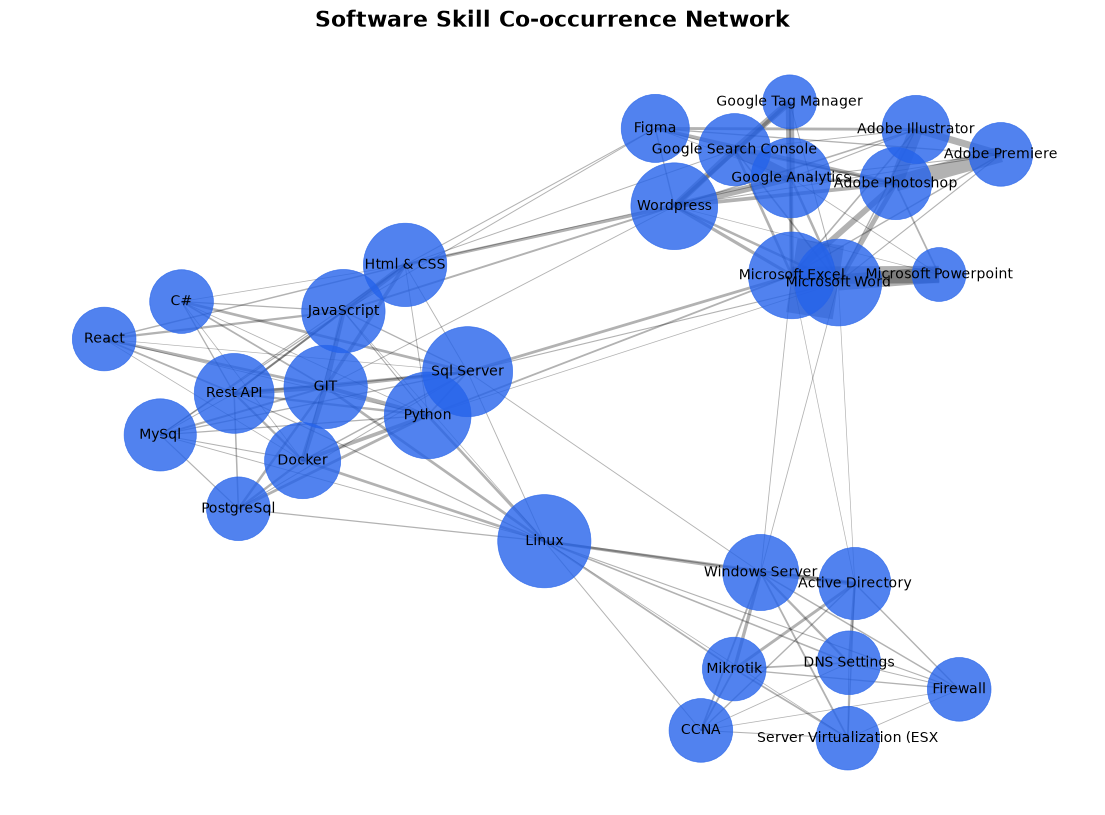

In [187]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,10))
top_nodes = (top_skills_network.head(30)["skill"].tolist())

G_sub = G.subgraph(top_nodes)

pos = nx.spring_layout(G_sub, k=1, seed=42)

node_sizes = [G_sub.degree(node) * 300 for node in G_sub.nodes()]

edge_widths = [G_sub[u][v]["weight"] / 20 for u, v in G_sub.edges()]

nx.draw_networkx_nodes(G_sub, pos, node_size=node_sizes, node_color="#2563EB", alpha=0.8)

nx.draw_networkx_edges(G_sub, pos, width=edge_widths, alpha=0.3)

nx.draw_networkx_labels(G_sub, pos, font_size=10)

plt.title("Software Skill Co-occurrence Network", fontsize=16, fontweight="bold")
plt.axis("off")
plt.show()

### Key Findings

- Skill combinations provide stronger signals of market value compared with individual skills, as employers usually look for combinations of technical capabilities rather than isolated technologies.

- Production-oriented engineering stacks show the highest salary premiums. Combinations such as Docker + RabbitMQ, Docker + Kafka, and Docker + Redis are associated with significantly higher median salaries, indicating strong demand for engineers who can build and maintain scalable systems.

- Backend engineering skills demonstrate a clear value pattern. Combinations involving programming languages, databases, and infrastructure technologies (such as Python + Redis, Docker + PostgreSQL, and PostgreSQL + Redis) consistently appear among higher-paying skill combinations.

- Docker acts as a salary multiplier rather than an independent skill. While Docker alone is associated with higher salaries, its combination with technologies such as Python, Redis, Kubernetes, and messaging systems creates significantly higher market value.

- Database and infrastructure skills have strong salary impact. Technologies such as Redis, PostgreSQL, Kubernetes, and Docker frequently appear in high-paying combinations, suggesting that companies place a premium on candidates who understand production-level systems.

- The analysis suggests that career growth is driven not only by learning individual technologies but also by developing complementary skill stacks. For example, a Python developer can increase market competitiveness by adding backend frameworks, database technologies, and deployment skills.

- Skill combination analysis provides valuable insights for recommendation systems, as it enables identifying the most valuable next skills for candidates based on their existing skill set and current market demand.